In [ ]:
!pip install datasets
!pip install --upgrade --quiet pip
!pip install --upgrade --quiet datasets[audio] transformers accelerate evaluate jiwer tensorboard gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.3/179.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2024.10.0
    Uninstalling fsspec-2024.10.0:
      Successfully uninstalled fsspec-2024.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2024.10.0 requires fsspec==2024.10.0, but you have fsspec 2024.9.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 82.6 MB/s eta 0:00:00
   ━━

In [ ]:
import torch

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from dataloader import Dataloader
from model_wrapper import WhisperWrapper
from model_evaluator import WhisperEvaluator
from feature_densities import build_feature_densities_estimation, eval_likelihood_all_audios

avail_dev = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device: ", avail_dev)

Using device:  cuda


In [ ]:
def plot_uq(base_hist, base_buckets, target_ds, target_audios, model_wrap, evaluator):
    # Calculate UQ for target data
    uq_scores_test = eval_likelihood_all_audios(model_wrap, target_audios, base_hist, base_buckets)
    # Compute transcription
    transcriptions_list, gt_list = evaluator.transcribe_dataset(target_ds)
    # Fetch WERS
    wers = evaluator.compute_wers(transcriptions_list, gt_list)

    # Plot results
    wers_np = np.array(wers)
    uq_scores_fd_np = np.array(uq_scores_test)

    plt.scatter(uq_scores_fd_np, wers_np)
    plt.xlabel("UQ Score")
    plt.ylabel("WER")
    plt.show()

    pearson_corr = np.corrcoef(uq_scores_fd_np, wers_np)[0, 1]
    mean_wer = np.mean(wers_np)
    std_wer = np.std(wers_np)
    #print(f"Average WER: {mean_wer:.4f}\nStd WER: {std_wer:.4f}")
    #print(f"Pearson correlation coefficient: {pearson_corr:.4f}")
    return mean_wer, std_wer, pearson_corr

In [ ]:
pip install --upgrade transformers

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
whisper_path = "/content/drive/My Drive/Whisper"
print(os.listdir(whisper_path))

['whisper_1', 'processor_1', 'tokenizer_1']


In [ ]:
# Create model
model_wrap = WhisperWrapper(model_path="/content/drive/My Drive/Whisper", device=avail_dev)
# Create evaluator
whisper_evaluator = WhisperEvaluator(model = model_wrap.model_cond_gen, processor = model_wrap.processor)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

In [ ]:
# Load data
featured_df, featured_audios = Dataloader.load_dataset_raw_uq(partition_type = "fine_tuning_partition",
                                                              partition_id = "fine_tuning_partition")
#calibration_ds, calibration_audios = Dataloader.load_uq_partitions("calibration")
#finetune_ds, finetune_audios = Dataloader.load_uq_partitions("fine-tune")
test_ds, test_audios = Dataloader.load_uq_partitions("test", 1, 11)

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

partition_0/FD_training_data.csv:   0%|          | 0.00/17.6k [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/2.31k [00:00<?, ?B/s]

(…)ning_partition/fine_tuning_partition.csv:   0%|          | 0.00/320k [00:00<?, ?B/s]

partition_1/calibration.csv:   0%|          | 0.00/20.0k [00:00<?, ?B/s]

...

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Fetching 75 files:   0%|          | 0/75 [00:00<?, ?it/s]

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.43.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


Extracting embeddings:   0%|          | 0/1999 [00:00<?, ?it/s]

Processing partitions:   0%|          | 0/9 [00:00<?, ?it/s]

Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

You have passed task=transcribe, but also have set `forced_decoder_ids` to [(1, 50262), (2, 50359), (3, 50363)] which creates a conflict. `forced_decoder_ids` will be ignored in favor of task=transcribe.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


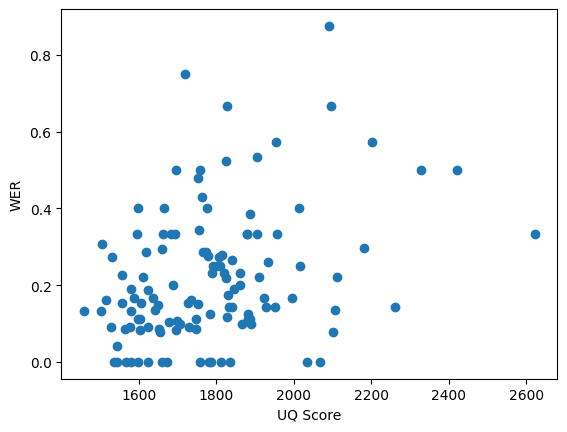

Partition 0 - Mean WER: 0.2190, Std WER: 0.1717, Pearson correlation coefficient: 0.3451


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

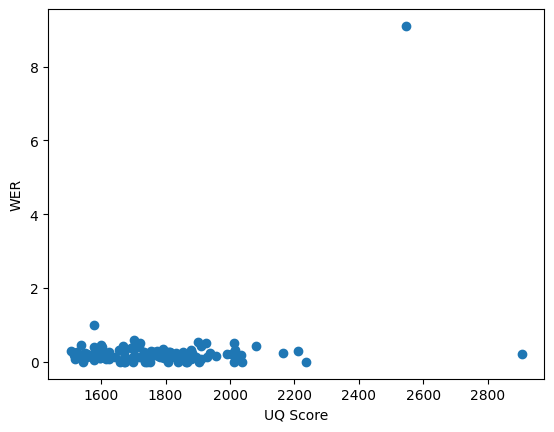

Partition 1 - Mean WER: 0.2813, Std WER: 0.8231, Pearson correlation coefficient: 0.3335


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

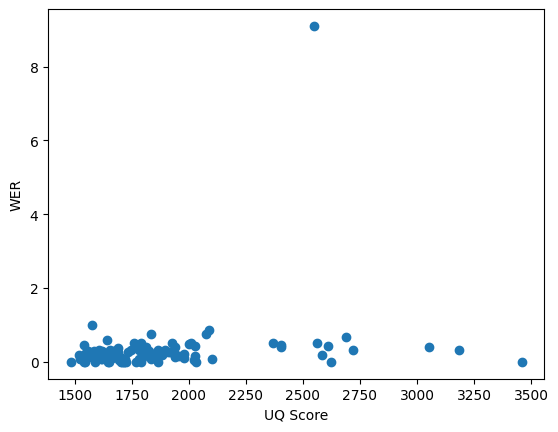

Partition 2 - Mean WER: 0.3054, Std WER: 0.8284, Pearson correlation coefficient: 0.2329


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

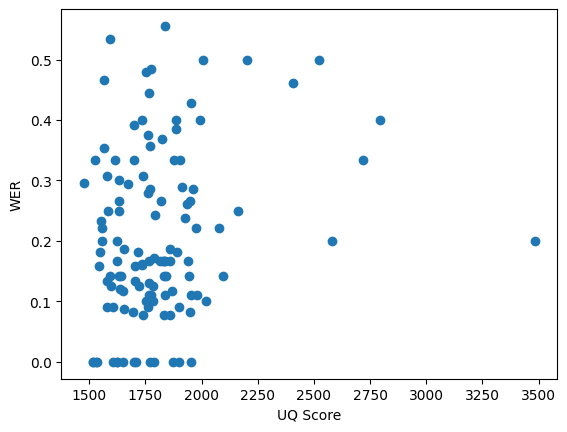

Partition 3 - Mean WER: 0.2060, Std WER: 0.1403, Pearson correlation coefficient: 0.2337


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

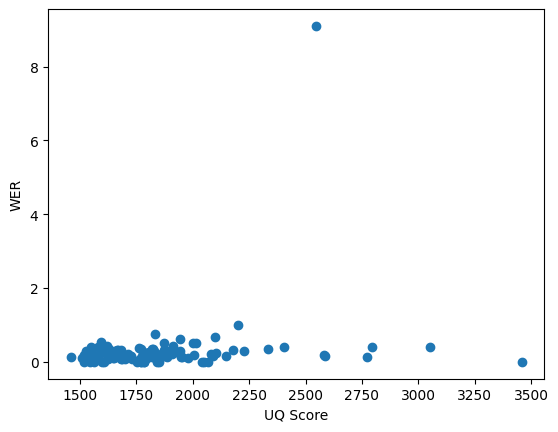

Partition 4 - Mean WER: 0.2912, Std WER: 0.8247, Pearson correlation coefficient: 0.2326


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

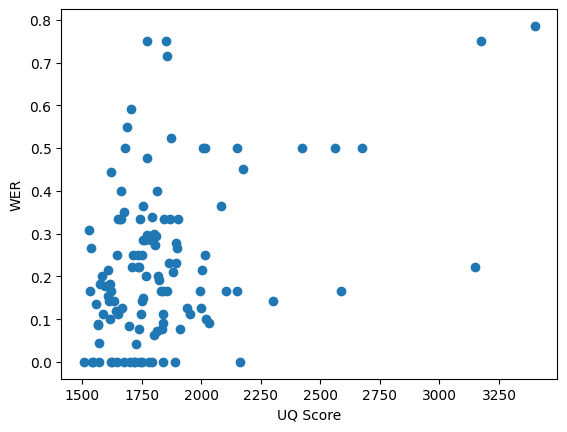

Partition 5 - Mean WER: 0.2267, Std WER: 0.1841, Pearson correlation coefficient: 0.4105


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

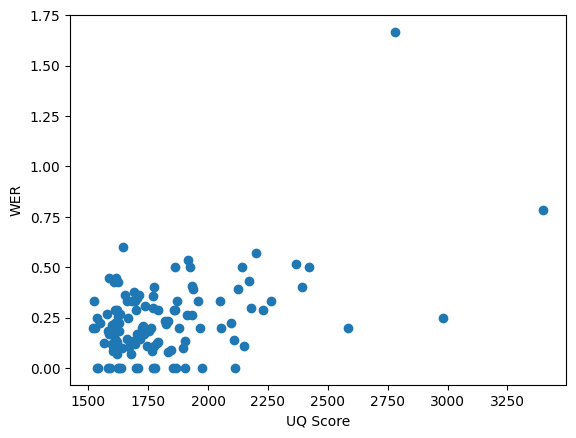

Partition 6 - Mean WER: 0.2377, Std WER: 0.2023, Pearson correlation coefficient: 0.4864


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

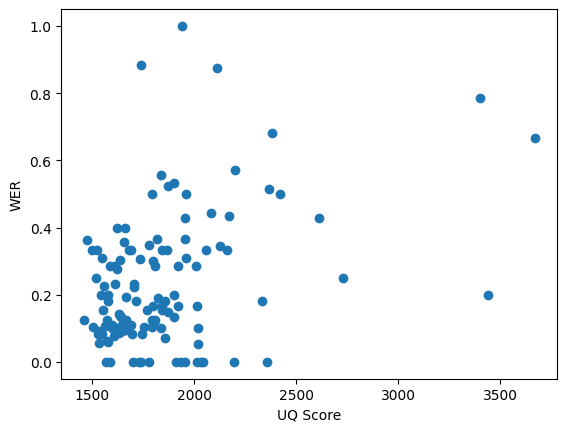

Partition 7 - Mean WER: 0.2334, Std WER: 0.1984, Pearson correlation coefficient: 0.3804


Evaluating likelihood:   0%|          | 0/120 [00:00<?, ?it/s]

Tanscribing audio:   0%|          | 0/120 [00:00<?, ?it/s]

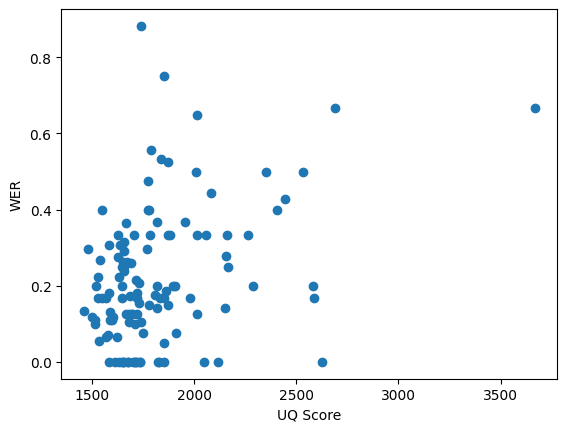

Partition 8 - Mean WER: 0.2171, Std WER: 0.1766, Pearson correlation coefficient: 0.3754
=============== Results ===============
    Partition         R  Mean WER   Std WER
0          0  0.345093  0.218966  0.171679
1          1  0.333496  0.281326  0.823102
2          2  0.232869  0.305386  0.828395
3          3  0.233681  0.205980  0.140332
4          4  0.232612  0.291216  0.824666
5          5  0.410508  0.226660  0.184113
6          6  0.486443  0.237704  0.202348
7          7  0.380440  0.233382  0.198414
8          8  0.375398  0.217066  0.176632
=============== Mean results ===============
 Partition    4.000000
R            0.336727
Mean WER     0.246409
Std WER      0.394409
dtype: float64


In [ ]:
# Use FD training data to estimate feature densities
histograms_all_features, buckets_all_features = build_feature_densities_estimation(model_wrap, featured_audios)

# Collect data for each partition
mean_wers = []
std_wers = []
pearson_corrs = []
partitions = list(range(9))
for i in tqdm(partitions, desc = "Processing partitions", leave=False):
    mean_wer, std_wer, pearson_corr = plot_uq(histograms_all_features, buckets_all_features, test_ds[i], test_audios[i], model_wrap, whisper_evaluator)
    mean_wers.append(mean_wer)
    std_wers.append(std_wer)
    pearson_corrs.append(pearson_corr)
    print(f"Partition {i} - Mean WER: {mean_wer:.4f}, Std WER: {std_wer:.4f}, Pearson correlation coefficient: {pearson_corr:.4f}")

# Print results
res = pd.DataFrame({"Partition": partitions, "R": pearson_corrs, "Mean WER": mean_wers, "Std WER": std_wers})
print("=============== Results ===============\n", res)
print("=============== Mean results ===============\n", res.mean())
res.to_csv("results.csv", index = False)